In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv",encoding="ISO-8859-1")
df.head()

df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='object')

In [3]:
df["created_year"].isna().sum()

np.int64(5)

In [4]:
# columns to be used for multivariate analysis
Analysis_cols_V2 = ["Youtuber","Country","channel_type","subscribers","video views","uploads","lowest_monthly_earnings","highest_monthly_earnings","lowest_yearly_earnings","highest_yearly_earnings",
                 "subscribers_for_last_30_days","video_views_for_the_last_30_days","created_year","Population"]

In [5]:
df =pd.read_csv("/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_duplicates_dropped.csv",encoding="ISO-8859-1",usecols=Analysis_cols_V2) 
df.head()

,Youtuber,subscribers,video views,uploads,Country,channel_type,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,lowest_yearly_earnings,highest_yearly_earnings,subscribers_for_last_30_days,created_year,Population
0,T-Series,245000000,2.280000e+11,20082,India,Music,2.258000e+09,564600.0,9000000.00,6800000.00,1.084000e+08,2000000.0,2006.0,1.366418e+09
1,YouTube Movies,170000000,0.000000e+00,1,United States,Games,1.200000e+01,0.0,0.05,0.04,5.800000e-01,NaN,2006.0,3.282395e+08
2,MrBeast,166000000,2.836884e+10,741,United States,Entertainment,1.348000e+09,337000.0,5400000.00,4000000.00,6.470000e+07,8000000.0,2012.0,3.282395e+08
3,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,966,United States,Education,1.975000e+09,493800.0,7900000.00,5900000.00,9.480000e+07,1000000.0,2006.0,3.282395e+08
4,SET India,159000000,1.480000e+11,116536,India,Entertainment,1.824000e+09,455900.0,7300000.00,5500000.00,8.750000e+07,1000000.0,2006.0,1.366418e+09


In [6]:
df["Country"] = df["Country"].fillna("Unknown")

In [7]:
df.isna().mean()

Youtuber                            0.000000
subscribers                         0.000000
video views                         0.000000
uploads                             0.000000
Country                             0.000000
channel_type                        0.030151
video_views_for_the_last_30_days    0.056281
lowest_monthly_earnings             0.000000
highest_monthly_earnings            0.000000
lowest_yearly_earnings              0.000000
highest_yearly_earnings             0.000000
subscribers_for_last_30_days        0.338693
created_year                        0.005025
Population                          0.123618
dtype: float64

In [8]:
df["channel_type"].nunique()

14

In [9]:
df.to_csv("/home/umoujahid/visualisation_project/data/Global-YouTube-Statistics_multivariate_analysis.csv",index=False)

## Analyse des performances des 30 derniers jours de la période observée

<div style="border-left:6px solid #8cc6ed; padding:12px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Analyser des profils multivariés** </div>

<div style="border-left:6px solid #c5cace; padding:11px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Parallel coordinates** </div>

In [10]:
from pandas.plotting import parallel_coordinates

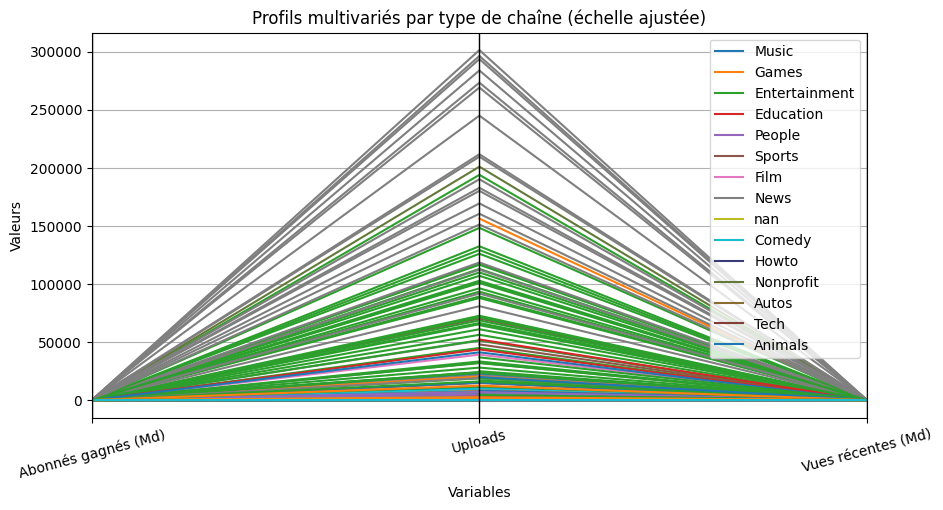

In [11]:
# conversion en milliards pour améliorer la lisibilité des variables de volume

df_parallel = df[["channel_type","subscribers_for_last_30_days","uploads","video_views_for_the_last_30_days"]].copy()
df_parallel["subscribers_for_last_30_days"] = df_parallel["subscribers_for_last_30_days"] / 1e9
df_parallel["video_views_for_the_last_30_days"] = df_parallel["video_views_for_the_last_30_days"] / 1e9

plt.figure(figsize=(10,5))

parallel_coordinates(
    df_parallel,
    class_column="channel_type",
    color=[
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#393b79", "#637939",
        "#8c6d31", "#843c39"
    ]
)

plt.title("Profils multivariés par type de chaîne (échelle ajustée)")
plt.xlabel("Variables")
plt.ylabel("Valeurs")
plt.xticks(
    ticks=range(3),
    labels=["Abonnés gagnés (Md)", "Uploads", "Vues récentes (Md)"],
    rotation=15
)

plt.show()


**Observations — graphique 1 :**

- Les variables liées aux abonnés et aux vues ont été transformées en **milliards (Md)**, ce qui rend la lecture de l’échelle plus cohérente.
- Même après cet ajustement, les profils restent dispersés : cela confirme une forte hétérogénéité entre les types de chaînes.
- Les volumes d’uploads restent sur une logique différente, ce qui montre que la comparaison brute doit être interprétée avec prudence.

/tmp/ipykernel_12267/87127708.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 20), random_state=42))


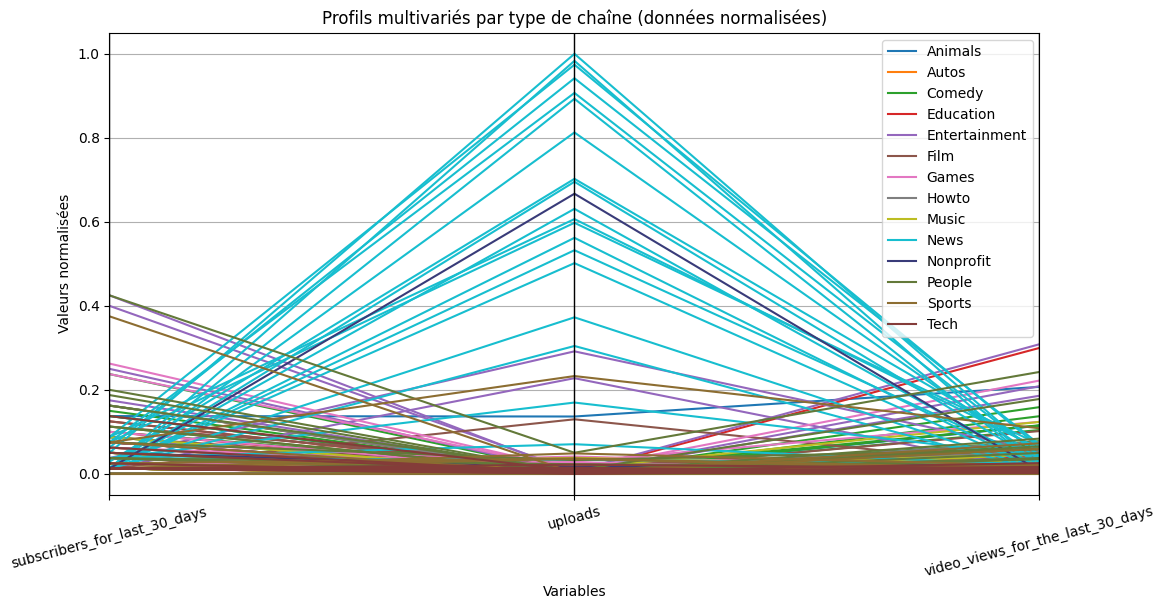

In [12]:
from sklearn.preprocessing import MinMaxScaler

# normalisation
cols = ["subscribers_for_last_30_days", "uploads", "video_views_for_the_last_30_days"]
scaler = MinMaxScaler()
df_scaled = df.dropna(subset=cols + ["channel_type"]).copy()
df_scaled[cols] = scaler.fit_transform(df_scaled[cols])

# échantillon pour améliorer la lisibilité
df_sample = (
    df_scaled.groupby("channel_type", group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 20), random_state=42))
)

# plot
plt.figure(figsize=(12,6))

parallel_coordinates(
    df_sample[cols + ["channel_type"]],
    class_column="channel_type",
    color=[
        "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
        "#9467bd", "#8c564b", "#e377c2", "#7f7f7f",
        "#bcbd22", "#17becf", "#393b79", "#637939",
        "#8c6d31", "#843c39"
    ]
)

plt.title("Profils multivariés par type de chaîne (données normalisées)")
plt.xlabel("Variables")
plt.ylabel("Valeurs normalisées")
plt.xticks(rotation=15)

plt.show()

**Observations — graphique 2 :**

- Après normalisation, la comparaison entre types de chaînes devient plus lisible.
- On observe que certaines catégories combinent davantage de vues récentes et de gains d’abonnés, alors que d’autres se distinguent surtout par le volume d’uploads.
- La normalisation confirme que la performance récente ne dépend pas uniquement de la fréquence de publication.


<div style="border-left:6px solid #c5cace; padding:11px; background:#f4f8fb; border-radius:10px; max-width:98%">

#### **Nuage de points multivarié (Scatter plot)** </div>


In [13]:
top_countries = df["Country"].value_counts().head(5).index
df_top = df[df["Country"].isin(top_countries)]

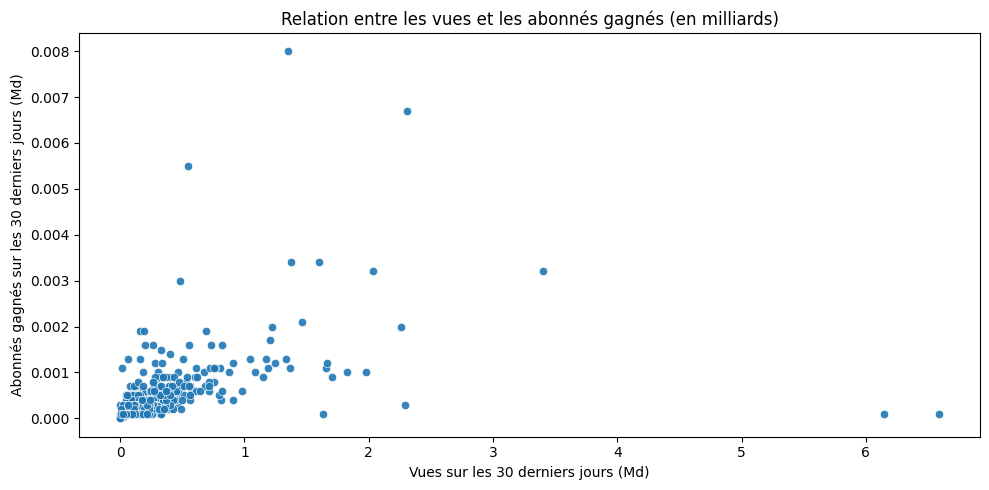

In [14]:
# conversion en milliards pour les axes du nuage de points

df_scatter = df.copy()
df_scatter["video_views_for_the_last_30_days_billion"] = df_scatter["video_views_for_the_last_30_days"] / 1e9
df_scatter["subscribers_for_last_30_days_billion"] = df_scatter["subscribers_for_last_30_days"] / 1e9

plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_scatter,
    x="video_views_for_the_last_30_days_billion",
    y="subscribers_for_last_30_days_billion",
    alpha=0.9
)

plt.title("Relation entre les vues et les abonnés gagnés (en milliards)")
plt.xlabel("Vues sur les 30 derniers jours (Md)")
plt.ylabel("Abonnés gagnés sur les 30 derniers jours (Md)")

plt.tight_layout()
plt.show()


**Observations — graphique 3 :**

- Le passage en **milliards (Md)** rend l’échelle plus lisible et facilite l’interprétation des écarts entre chaînes.
- La relation entre les vues récentes et les abonnés gagnés reste globalement positive.
- La dispersion importante indique toutefois que la conversion des vues en abonnés n’est pas identique pour toutes les chaînes.

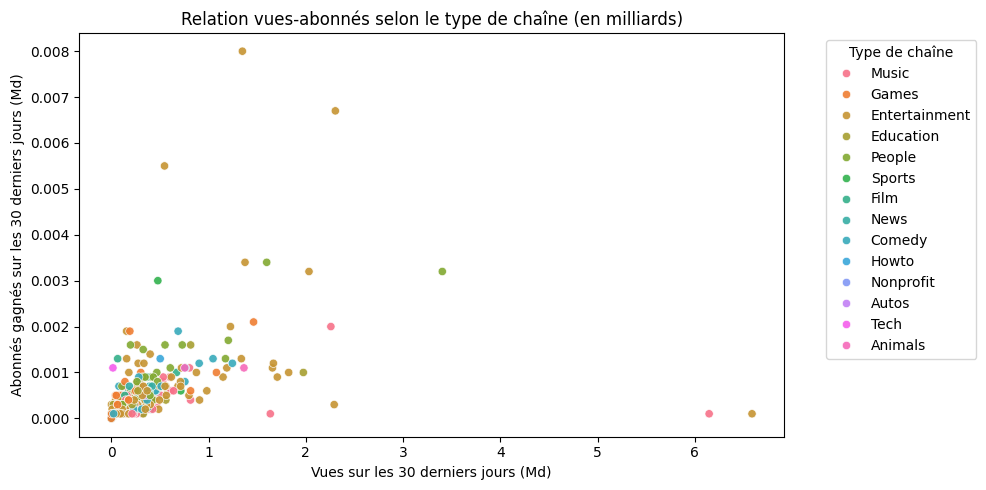

In [15]:
plt.figure(figsize=(10,5))

sns.scatterplot(
    data=df_scatter,
    x="video_views_for_the_last_30_days_billion",
    y="subscribers_for_last_30_days_billion",
    hue="channel_type",
    alpha=0.9
)

plt.title("Relation vues-abonnés selon le type de chaîne (en milliards)")
plt.xlabel("Vues sur les 30 derniers jours (Md)")
plt.ylabel("Abonnés gagnés sur les 30 derniers jours (Md)")

plt.legend(title="Type de chaîne", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


**Observations — graphique 4 :**

- L’ajout de la couleur montre que les performances ne sont pas uniformes selon le type de chaîne.
- Les catégories dominantes, notamment *Entertainment* et *Music*, occupent une large partie de l’espace et semblent concentrer les plus fortes performances récentes.
- D’autres catégories apparaissent plus dispersées ou plus modestes, ce qui peut refléter des audiences plus spécialisées.

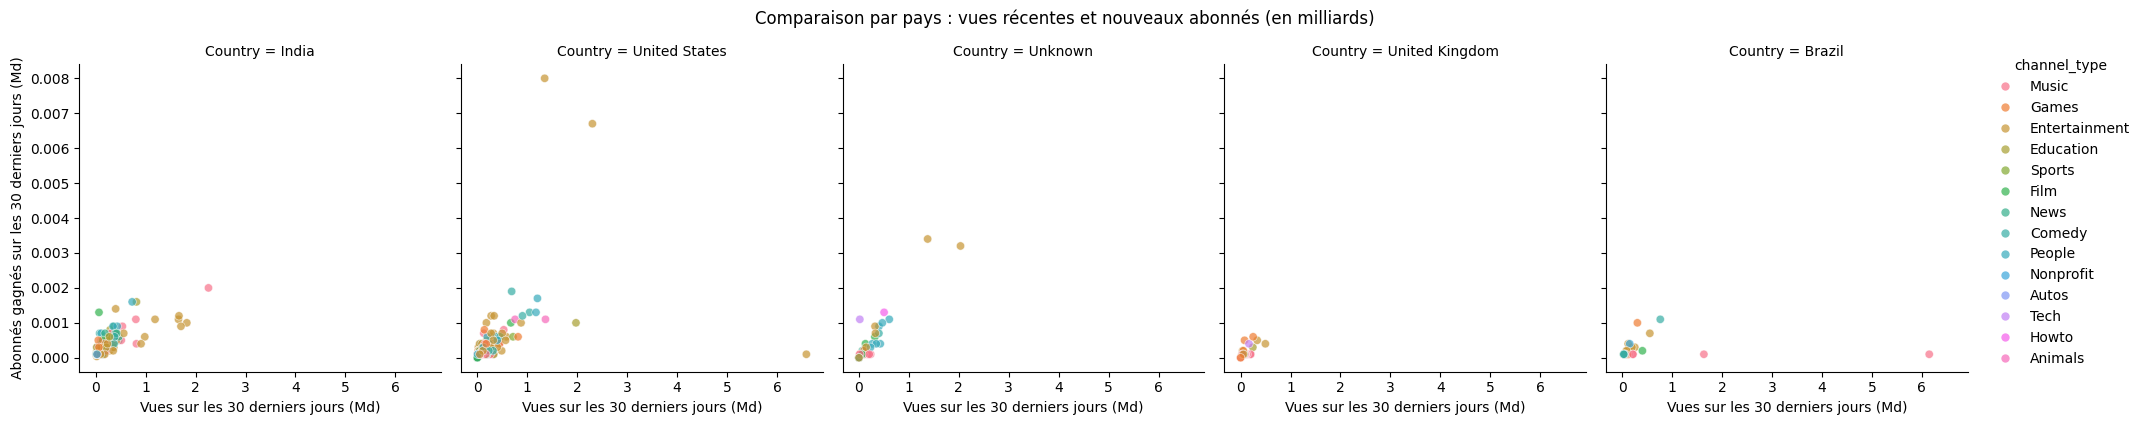

In [16]:
df_top_plot = df_top.copy()
df_top_plot["video_views_for_the_last_30_days_billion"] = df_top_plot["video_views_for_the_last_30_days"] / 1e9
df_top_plot["subscribers_for_last_30_days_billion"] = df_top_plot["subscribers_for_last_30_days"] / 1e9

g = sns.relplot(
    data=df_top_plot,
    x="video_views_for_the_last_30_days_billion",
    y="subscribers_for_last_30_days_billion",
    hue="channel_type",
    col="Country",
    alpha=0.7,
    height=4
)

g.fig.suptitle("Comparaison par pays : vues récentes et nouveaux abonnés (en milliards)", y=1.05)
g.set_axis_labels("Vues sur les 30 derniers jours (Md)", "Abonnés gagnés sur les 30 derniers jours (Md)")

plt.show()


**Observations — graphique 5 :**

- La facettisation par pays montre que la relation vues-abonnés existe dans plusieurs contextes géographiques, mais avec des intensités différentes.
- Les pays les plus représentés présentent aussi la plus grande variabilité, ce qui traduit la diversité des chaînes présentes dans ces marchés.
- La structure par pays suggère que le contexte géographique complète l’effet du type de chaîne dans l’explication des performances.

<div style="border-left:6px solid ; padding:12px; border-radius:10px; max-width:98%">

#### **Décision finale**

L’analyse multivariée montre que les **vues des 30 derniers jours** sont le facteur le plus directement associé aux **abonnés gagnés sur la même période**. Les performances varient ensuite selon le **type de chaîne** et, dans une moindre mesure, selon le **pays**. En revanche, le nombre d’**uploads** n’explique pas à lui seul les meilleurs résultats.